<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/Louiza_AKHAM__AI_Workshop_Part_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Réalisé par Louiza AKHAM

Chargement et Exploration des Données
Dans cette partie nous allons exécuter les différentes étapes sur une base de données impoté depuis Kaggle intitulée: Spotify_insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Chargement des données Spotify
df_spotify = pd.read_csv('spotify_analysis_dataset.csv')
df_spotify['release_date'] = pd.to_datetime(df_spotify['release_date'])

# Création de caractéristiques supplémentaires
df_spotify['duration_min'] = df_spotify['duration_ms'] / 60000
df_spotify['release_year'] = df_spotify['release_date'].dt.year
df_spotify['release_month'] = df_spotify['release_date'].dt.month
df_spotify['energy_dance_ratio'] = df_spotify['energy'] / (df_spotify['danceability'] + 0.001)
df_spotify['acoustic_score'] = df_spotify['acousticness'] * 100

print(f"Dataset Shape: {df_spotify.shape}")
print(f"Date Range: {df_spotify['release_date'].min()} to {df_spotify['release_date'].max()}")
print(f" Missing Values:\n{df_spotify.isnull().sum()}")
print(f"\n Summary Statistics:")
print(df_spotify[['popularity', 'duration_min', 'danceability', 'energy', 'tempo']].describe())

Dataset Shape: (50, 21)
Date Range: 2010-01-01 00:00:00 to 2010-02-19 00:00:00
 Missing Values:
track_id              0
track_name            0
artist                0
album                 0
release_date          0
duration_ms           0
popularity            0
danceability          0
energy                0
loudness              0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_min          0
release_year          0
release_month         0
energy_dance_ratio    0
acoustic_score        0
dtype: int64

 Summary Statistics:
       popularity  duration_min  danceability     energy       tempo
count   50.000000     50.000000      50.00000  50.000000   50.000000
mean    50.320000      3.545435       0.47420   0.506000  126.094000
std     27.528419      0.795425       0.29023   0.299962   39.179744
min      0.000000      2.139867       0.01700   0.005000   62.040000
25%     27.500000   

Visualisations avec Matplotlib/Seaborn
1-Distribution de la Popularité

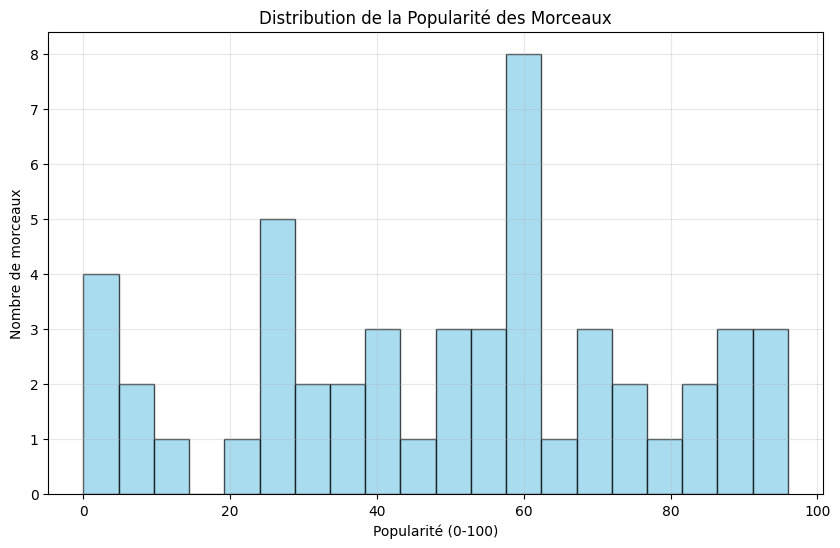

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_spotify['popularity'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution de la Popularité des Morceaux')
plt.xlabel('Popularité (0-100)')
plt.ylabel('Nombre de morceaux')
plt.grid(True, alpha=0.3)
plt.show()

2- Relation Danceabilité vs Énergie

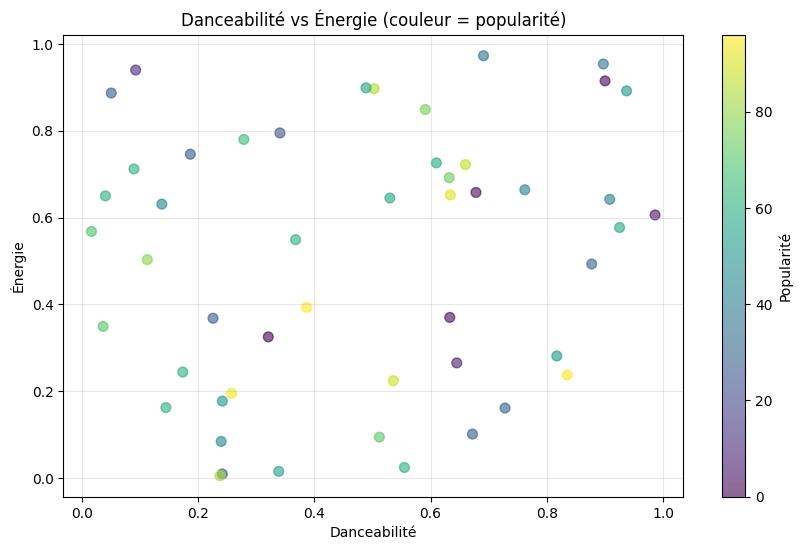

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_spotify['danceability'], df_spotify['energy'],
            alpha=0.6, c=df_spotify['popularity'], cmap='viridis', s=50)
plt.colorbar(label='Popularité')
plt.title('Danceabilité vs Énergie (couleur = popularité)')
plt.xlabel('Danceabilité')
plt.ylabel('Énergie')
plt.grid(True, alpha=0.3)
plt.show()

3-Popularité par Artiste

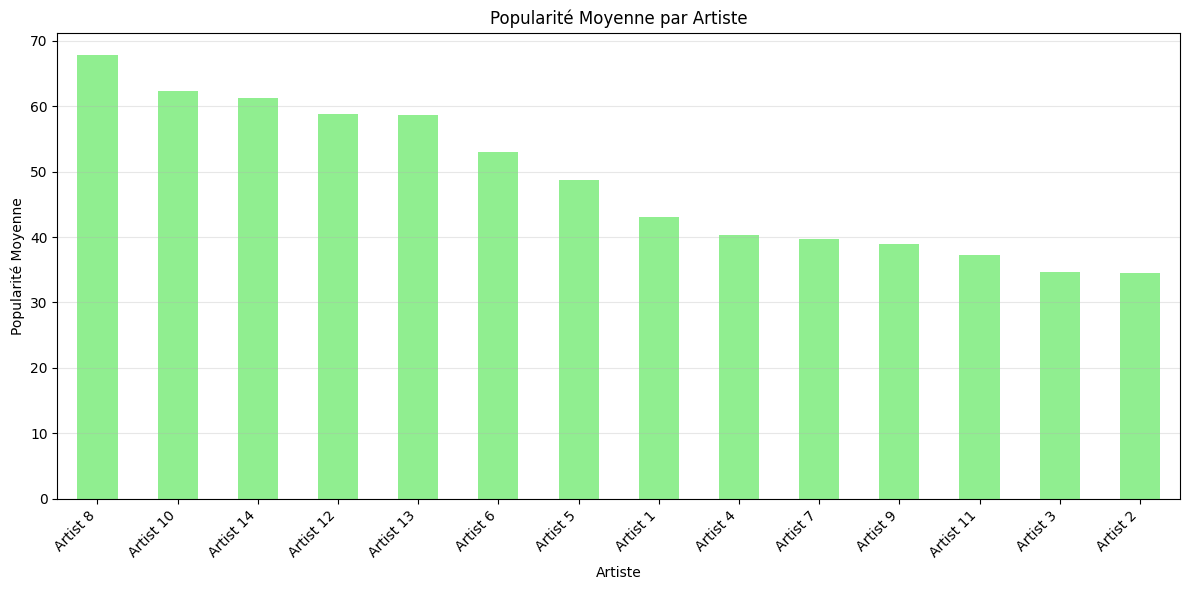

In [ ]:
plt.figure(figsize=(12, 6))
popularity_by_artist = df_spotify.groupby('artist')['popularity'].mean().sort_values(ascending=False)
popularity_by_artist.plot(kind='bar', color='lightgreen')
plt.title('Popularité Moyenne par Artiste')
plt.xlabel('Artiste')
plt.ylabel('Popularité Moyenne')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

4-Matrice de Corrélation des Caractéristiques Audio

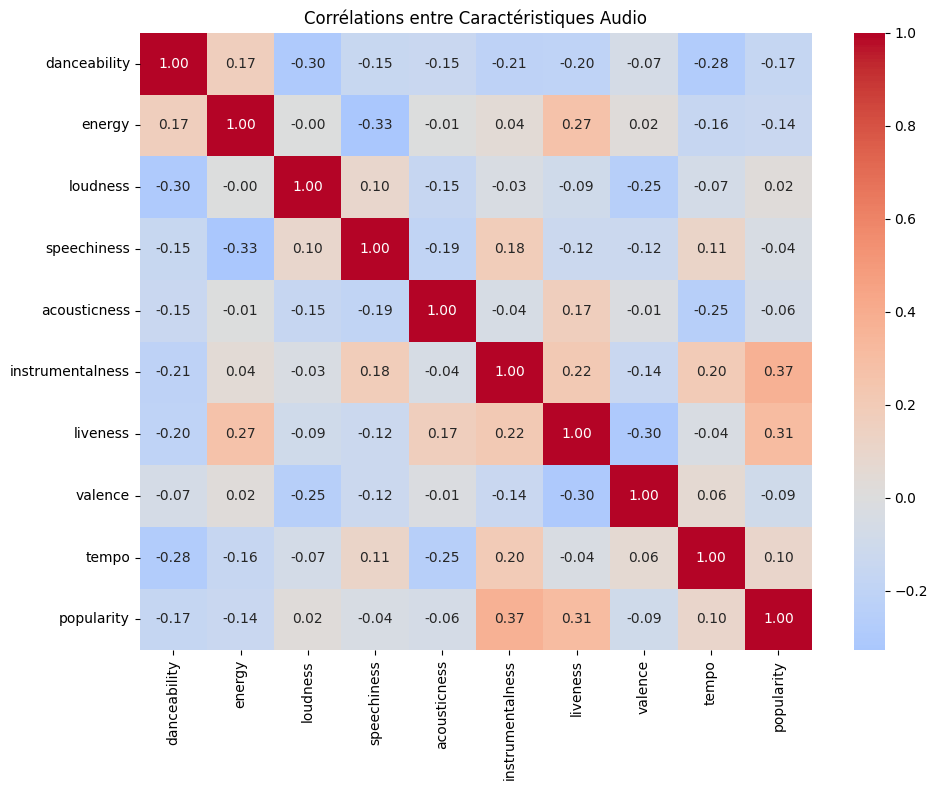

In [ ]:
plt.figure(figsize=(10, 8))
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']
correlation_matrix = df_spotify[audio_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Corrélations entre Caractéristiques Audio')
plt.tight_layout()
plt.show()

 5-Boxplot des Caractéristiques par Popularité

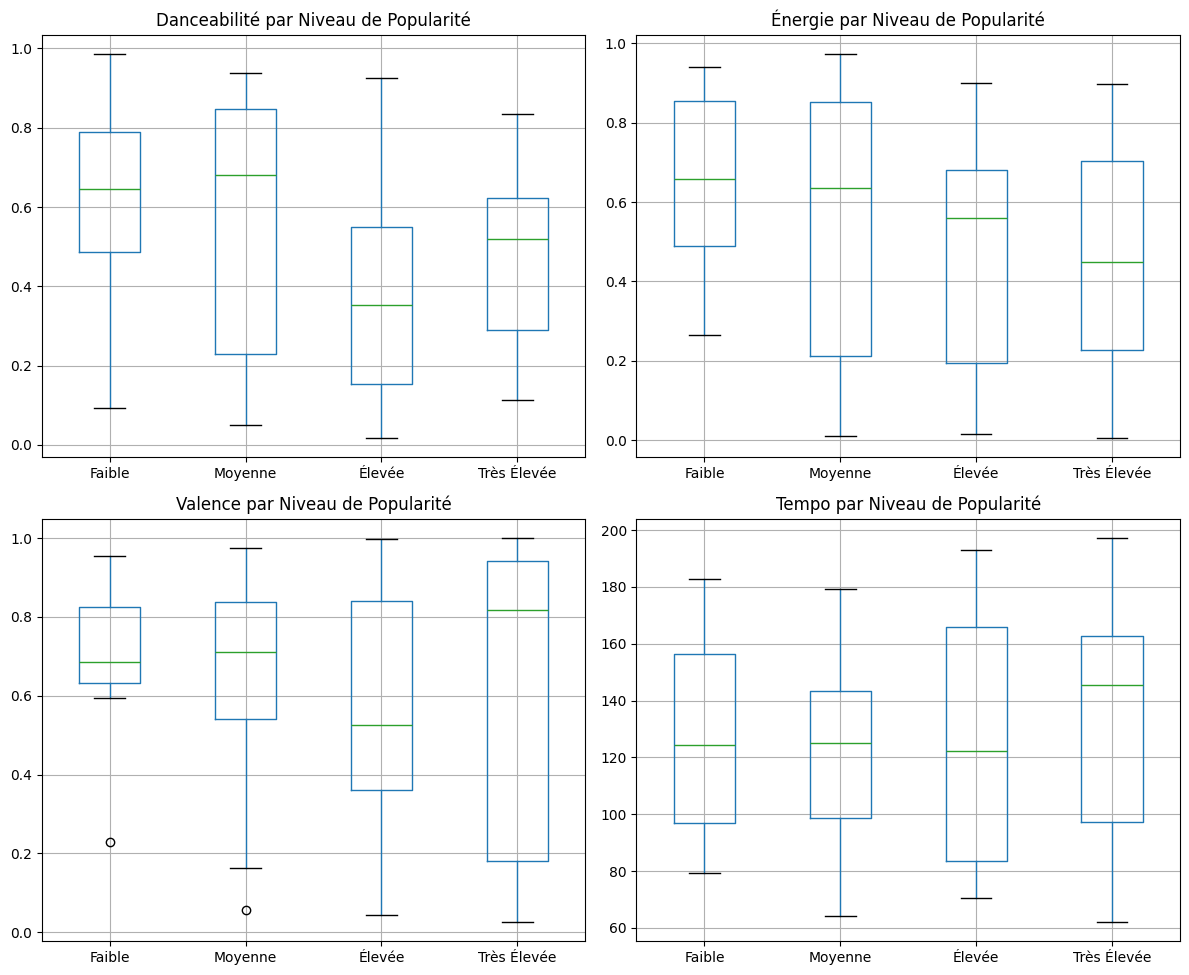

In [ ]:
# Catégoriser la popularité
df_spotify['popularity_group'] = pd.cut(df_spotify['popularity'],
                                        bins=[0, 25, 50, 75, 100],
                                        labels=['Faible', 'Moyenne', 'Élevée', 'Très Élevée'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Danceability
df_spotify.boxplot(column='danceability', by='popularity_group', ax=axes[0,0])
axes[0,0].set_title('Danceabilité par Niveau de Popularité')
axes[0,0].set_xlabel('')

# Energy
df_spotify.boxplot(column='energy', by='popularity_group', ax=axes[0,1])
axes[0,1].set_title('Énergie par Niveau de Popularité')
axes[0,1].set_xlabel('')

# Valence
df_spotify.boxplot(column='valence', by='popularity_group', ax=axes[1,0])
axes[1,0].set_title('Valence par Niveau de Popularité')
axes[1,0].set_xlabel('')

# Tempo
df_spotify.boxplot(column='tempo', by='popularity_group', ax=axes[1,1])
axes[1,1].set_title('Tempo par Niveau de Popularité')
axes[1,1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

 Visualisations Interactives avec Plotly

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

6-Nuage de points 3D interactif

In [ ]:
fig = px.scatter_3d(df_spotify,
                    x='danceability',
                    y='energy',
                    z='popularity',
                    color='valence',
                    size='duration_min',
                    hover_name='track_name',
                    hover_data=['artist', 'tempo'],
                    title='Visualisation 3D: Caractéristiques Musicales',
                    labels={'danceability': 'Danceabilité',
                            'energy': 'Énergie',
                            'popularity': 'Popularité',
                            'valence': 'Positivité',
                            'duration_min': 'Durée (min)'})
fig.update_layout(scene=dict(
                    xaxis_title='Danceabilité',
                    yaxis_title='Énergie',
                    zaxis_title='Popularité'))
fig.show()

7-Dashboard interactif Spotify

In [ ]:
# Créer un dashboard avec plusieurs graphiques
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Popularité vs Danceabilité', 'Distribution de l\'Énergie',
                    'Tempo par Artiste', 'Caractéristiques Audio'),
    specs=[[{'type': 'scatter'}, {'type': 'histogram'}],
           [{'type': 'box'}, {'type': 'heatmap'}]]
)

# Graphique 1: Scatter plot
fig.add_trace(
    go.Scatter(x=df_spotify['danceability'], y=df_spotify['popularity'],
               mode='markers', name='Morceaux',
               marker=dict(size=8, opacity=0.6, color=df_spotify['energy'],
                          colorscale='Viridis', showscale=True)),
    row=1, col=1
)

# Graphique 2: Histogramme
fig.add_trace(
    go.Histogram(x=df_spotify['energy'], nbinsx=20, name='Énergie',
                 marker_color='lightblue'),
    row=1, col=2
)

# Graphique 3: Boxplot
fig.add_trace(
    go.Box(x=df_spotify['artist'], y=df_spotify['tempo'], name='Tempo par artiste'),
    row=2, col=1
)

# Graphique 4: Heatmap
heatmap_features = ['danceability', 'energy', 'valence', 'acousticness', 'popularity']
corr_matrix = df_spotify[heatmap_features].corr()
fig.add_trace(
    go.Heatmap(z=corr_matrix.values,
               x=heatmap_features,
               y=heatmap_features,
               colorscale='RdBu',
               zmid=0,
               text=np.round(corr_matrix.values, 2),
               texttemplate='%{text}'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text="Analyse Spotify - Dashboard Interactif")
fig.update_xaxes(tickangle=45, row=2, col=1)
fig.show()

8-Graphique en radar des caractéristiques audio

In [ ]:
sample_track = df_spotify.sample(1).iloc[0]

fig = go.Figure(data=go.Scatterpolar(
    r=[sample_track['danceability'], sample_track['energy'],
       sample_track['valence'], sample_track['acousticness'],
       sample_track['liveness'], sample_track['danceability']],
    theta=['Danceabilité', 'Énergie', 'Positivité',
           'Acoustique', 'Vivacité', 'Danceabilité'],
    fill='toself',
    name=sample_track['track_name']
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    title=f"Profil Audio: {sample_track['track_name']} - {sample_track['artist']}"
)

fig.show()